##  Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt



## Load Dataset


In [4]:
df = pd.read_csv("upi_transactions_2024.csv")


## Display first 5 rows


In [5]:
df.head()


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


## Dataset Information


In [6]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   transaction id      250000 non-null  str  
 1   timestamp           250000 non-null  str  
 2   transaction type    250000 non-null  str  
 3   merchant_category   250000 non-null  str  
 4   amount (INR)        250000 non-null  int64
 5   transaction_status  250000 non-null  str  
 6   sender_age_group    250000 non-null  str  
 7   receiver_age_group  250000 non-null  str  
 8   sender_state        250000 non-null  str  
 9   sender_bank         250000 non-null  str  
 10  receiver_bank       250000 non-null  str  
 11  device_type         250000 non-null  str  
 12  network_type        250000 non-null  str  
 13  fraud_flag          250000 non-null  int64
 14  hour_of_day         250000 non-null  int64
 15  day_of_week         250000 non-null  str  
 16  is_weekend          250000 non-

## Number of rows and column

In [7]:
print(df.shape)

(250000, 17)


## MISSING VALUE

In [8]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

## Remove Duplicate Records

In [9]:
df = df.drop_duplicates()

## Convert Timestamp into Date Format

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

## Check Data Types

In [11]:
df.dtypes

transaction id                   str
timestamp             datetime64[us]
transaction type                 str
merchant_category                str
amount (INR)                   int64
transaction_status               str
sender_age_group                 str
receiver_age_group               str
sender_state                     str
sender_bank                      str
receiver_bank                    str
device_type                      str
network_type                     str
fraud_flag                     int64
hour_of_day                    int64
day_of_week                      str
is_weekend                     int64
dtype: object

## Create Amount Column

In [12]:
df.rename(columns={"amount (INR)": "Amount"}, inplace=True)

## Create Transaction Month Number

In [13]:
df["Month_Number"] = df["timestamp"].dt.month

## Create Transaction Status Flag

In [14]:
df["Successful"] = df["transaction_status"] == "Success"

In [15]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,Amount,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,Month_Number,Successful
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,10,False
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,4,False
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,4,False
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,1,False
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,1,False


# DATA ANALYSIS
## Total Transaction Value

In [16]:
total_amount = df["Amount"].sum()

print("Total Transaction Value:", total_amount)

Total Transaction Value: 327939009


## Total Successful Transactions

In [17]:
success = df[df["transaction_status"]=="Success"]

print(success.shape[0])

0


## Failed Transactions Count

In [19]:
failed = df[df["transaction_status"]=="Failed"]

print(failed.shape[0])

0


## Top 10 States by Transaction Amount

In [20]:
state_amount = df.groupby("sender_state")["Amount"].sum().sort_values(ascending=False)

print(state_amount.head(10))


sender_state
Maharashtra       49043948
Uttar Pradesh     40035717
Karnataka         38451158
Tamil Nadu        33343518
Delhi             32689865
Telangana         29750930
Rajasthan         26730470
Gujarat           25988190
Andhra Pradesh    25952619
West Bengal       25952594
Name: Amount, dtype: int64


## Most Popular Merchant Category

In [21]:
category_count = df["merchant_category"].value_counts()

print(category_count)

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64


## Revenue by Merchant Category

In [22]:
category_amount = df.groupby("merchant_category")["Amount"].sum().sort_values(ascending=False)

print(category_amount)

merchant_category
Shopping         76863207
Grocery          58277893
Utilities        52742482
Fuel             38982575
Education        38704346
Other            21073449
Food             19919402
Entertainment     8309080
Healthcare        6874159
Transport         6192416
Name: Amount, dtype: int64


## Monthly Transaction Amount

In [23]:
monthly_sales = df.groupby("Month_Number")["Amount"].sum()

print(monthly_sales)

Month_Number
1     27456691
2     25826330
3     27508202
4     26988791
5     28024857
6     27032118
7     28079905
8     27845907
9     27105761
10    27866829
11    26892531
12    27311087
Name: Amount, dtype: int64


## Fraud Analysis

In [24]:
fraud = df[df["fraud_flag"]==1]

print("Fraud Transactions:", fraud.shape[0])

print("Fraud Amount:", fraud["Amount"].sum())

Fraud Transactions: 480
Fraud Amount: 719631


## Most Used Sender Bank

In [25]:
bank = df["sender_bank"].value_counts()

print(bank.head())

sender_bank
SBI         62693
HDFC        37485
ICICI       29769
IndusInd    25173
Axis        25042
Name: count, dtype: int64


## Peak Transaction Hours

In [26]:
hours = df.groupby("hour_of_day")["transaction id"].count()

print(hours)

hour_of_day
0      3388
1      2244
2      1685
3      1314
4      1247
5      1742
6      3501
7      5630
8      8349
9     10450
10    13904
11    16328
12    17516
13    15038
14    11472
15    12624
16    13992
17    18340
18    20064
19    21232
20    18506
21    16253
22     9364
23     5817
Name: transaction id, dtype: int64


# Data Visualization
## Chart 1 — Bar Chart (Top States by Amount)

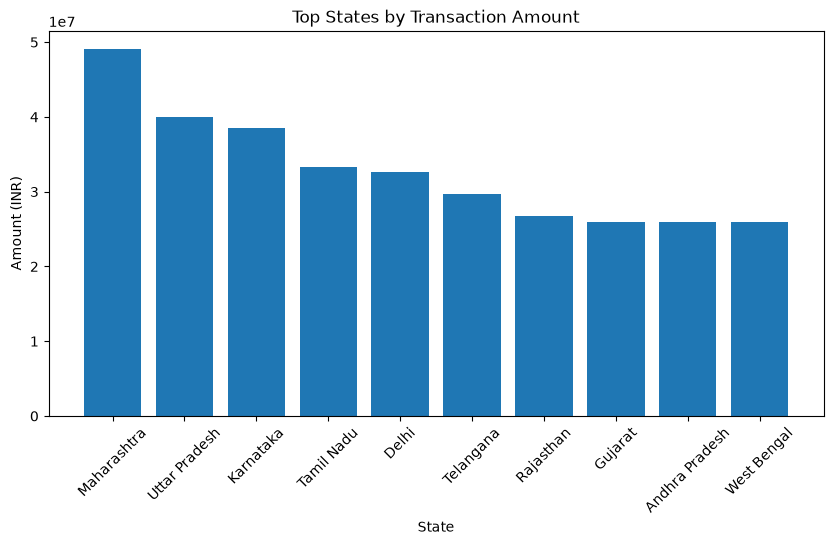

In [27]:
top_states = state_amount.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_states.index, top_states.values)

plt.title("Top States by Transaction Amount")

plt.xlabel("State")

plt.ylabel("Amount (INR)")

plt.xticks(rotation=45)

plt.show()

## Chart 2 — Pie Chart (Merchant Category Contribution)

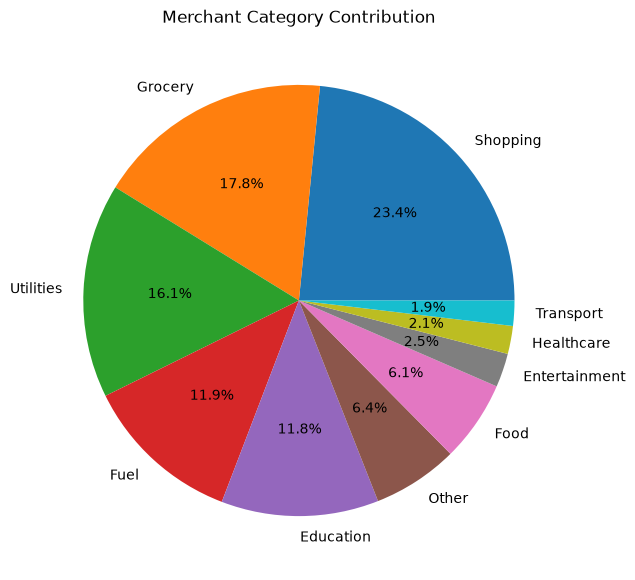

In [28]:
plt.figure(figsize=(7,7))

plt.pie(
    category_amount.values,
    labels=category_amount.index,
    autopct="%1.1f%%"
)

plt.title("Merchant Category Contribution")

plt.show()

## Chart 3 — Line Chart (Monthly Transactions)

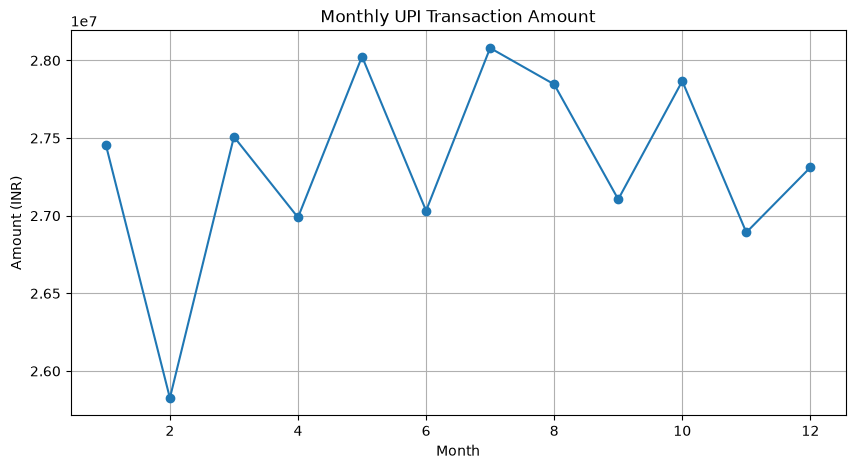

In [29]:
monthly_sales = monthly_sales.sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly UPI Transaction Amount")

plt.xlabel("Month")

plt.ylabel("Amount (INR)")

plt.grid()

plt.show()

## Chart 4 — Fraud vs Genuine Transactions

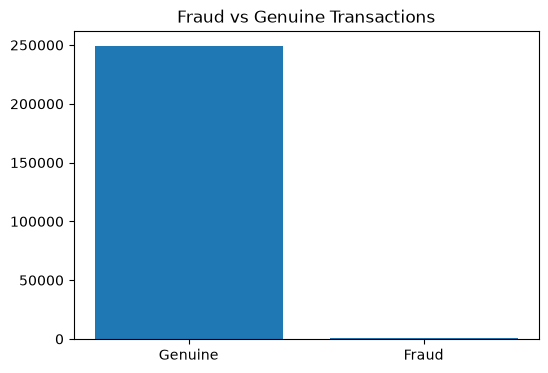

In [30]:
fraud_count = df["fraud_flag"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(["Genuine","Fraud"], fraud_count.values)

plt.title("Fraud vs Genuine Transactions")

plt.show()

## Chart 5 — Transactions by Hour

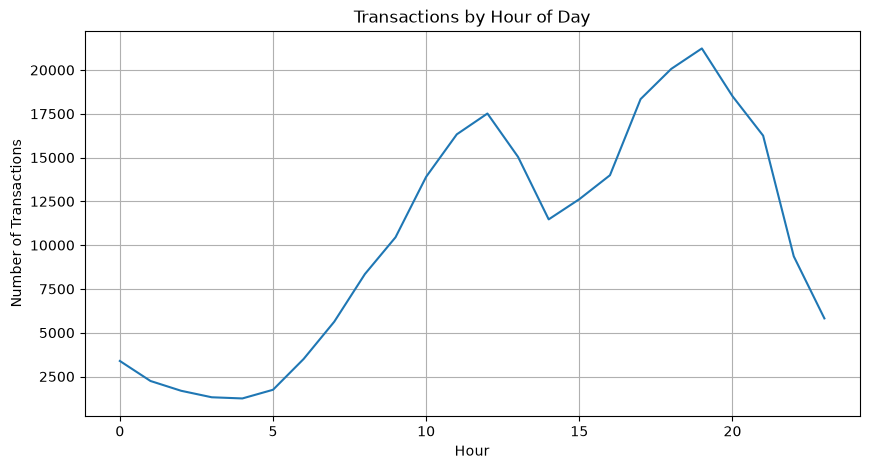

In [31]:
plt.figure(figsize=(10,5))

plt.plot(hours.index, hours.values)

plt.title("Transactions by Hour of Day")

plt.xlabel("Hour")

plt.ylabel("Number of Transactions")

plt.grid()

plt.show()

## Bonus 1 — Top 3 Merchant Categories by Amount

In [32]:
top3 = category_amount.head(3)

print(top3)

merchant_category
Shopping     76863207
Grocery      58277893
Utilities    52742482
Name: Amount, dtype: int64


## Bonus 2 — Average Transaction Value

In [33]:
average = df["Amount"].mean()

print("Average Transaction Value:", average)

Average Transaction Value: 1311.756036


## Bonus 3 — Top 5 Banks by Transaction Amount

In [34]:
banks = df.groupby("sender_bank")["Amount"].sum().sort_values(ascending=False)

print(banks.head())

sender_bank
SBI         82816520
HDFC        49791194
ICICI       38731193
IndusInd    32842711
Yes Bank    32492477
Name: Amount, dtype: int64


## Bonus 4 — Weekend vs Weekday

In [35]:
weekend = df.groupby("is_weekend")["Amount"].sum()

print(weekend)

is_weekend
0    234498529
1     93440480
Name: Amount, dtype: int64


## Bonus 5 — Age Group Analysis

In [36]:
age = df.groupby("sender_age_group")["Amount"].sum().sort_values(ascending=False)

print(age)

sender_age_group
26-35    115959771
36-45     89533745
18-25     74473936
46-55     33116261
56+       14855296
Name: Amount, dtype: int64
